# Hạ

In [ ]:
# Import các thư viện cần thiết
import sys
import os
import pandas as pd

# Thêm đường dẫn src vào PYTHONPATH để import các module
# Lấy thư mục cha của notebooks/ (tức là project root)
current_dir = os.getcwd()
# Nếu đang ở trong thư mục notebooks/, lên 1 cấp
if current_dir.endswith('notebooks'):
    project_root = os.path.dirname(current_dir)
else:
    project_root = current_dir

src_path = os.path.join(project_root, 'src')
sys.path.insert(0, src_path)

print("Đã import thành công các module cần thiết!")

In [ ]:
filepath = "../data/processed/fill_missing_values_data.csv"
df = pd.read_csv(filepath)

### **1️⃣ Sản phẩm từ xuất xứ (origin) nào thường có `rating_average` cao nhất, và xuất xứ (origin) nào đang chiếm ưu thế trên thị trường Tiki.**

**Câu hỏi này giúp:** xác định liệu các xuất xứ đang chiếm ưu thế về số lượng sản phẩm trên Tiki có đồng thời được người tiêu dùng đánh giá cao về chất lượng hay không.  
  
**Cách thức thực hiện:**

1. Tiền xử lý dữ liệu xuất xứ (origin):
Chuẩn hóa trường origin bằng cách tách các giá trị nhiều quốc gia, loại bỏ khoảng trắng và giá trị rỗng để đảm bảo mỗi sản phẩm chỉ gắn với một xuất xứ hợp lệ.

2. Gắn lại dữ liệu xuất xứ vào tập dữ liệu gốc:
Sau khi tách origin, liên kết lại với các biến liên quan như `rating_average` và `quantity_sold` để phục vụ phân tích.

3. Phân tích mức độ chiếm ưu thế của xuất xứ:
Đếm số lượng sản phẩm theo từng xuất xứ nhằm xác định các quốc gia có độ phủ thị trường cao nhất trên Tiki.

4. Phân tích chất lượng cảm nhận theo xuất xứ:
Tính giá trị `rating_average` trung bình của từng xuất xứ để xác định xuất xứ nào được người tiêu dùng đánh giá cao nhất.

5. Trực quan hóa và so sánh:
Sử dụng biểu đồ cột để so sánh giữa độ phổ biến và mức đánh giá trung bình, từ đó rút ra nhận định về mối quan hệ giữa quy mô thị trường và chất lượng đánh giá.

In [ ]:
# Bước 1: Chuẩn hoá + split
origin_exploded = (
    df['origin']
    .str.replace('/', ',', regex=False)
    .str.replace(';', ',', regex=False)
    .str.split(',')
    .explode()
    .str.strip()
    .replace('', pd.NA)
    .dropna()
)

# Bước 2: Tạo cột mới cho origin đã clean và được tách
df_origin = df.loc[origin_exploded.index].copy()
df_origin['origin_clean'] = origin_exploded

df_origin.head(5)

In [ ]:
# Bước 3: Đếm tần suất các quốc gia (lấy 20 quốc gia cao nhất)
origin_count = (
    df_origin['origin_clean']
    .value_counts()
    .head(20)
)
origin_count.head(5)

In [ ]:
# Bước 4: Tính average rating giữa các quốc gia (lấy 20 quốc gia cao nhất)
origin_rating = (
    df_origin
    .groupby('origin_clean')['rating_average']
    .mean()
    .sort_values(ascending=False)
    .head(20)
)
origin_rating.head(5)

In [ ]:
# Bước 5: Visualizing
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Biểu đồ 1: Độ phổ biến
axes[0].barh(origin_count.index, origin_count.values, color = "#E91B5F", alpha = 0.5)
axes[0].set_title('Top 20 Origins by Product Count')
axes[0].set_xlabel('Number of Products')
axes[0].set_ylabel('Origin')
axes[0].invert_yaxis()

# Biểu đồ 2: Rating trung bình
axes[1].barh(origin_rating.index, origin_rating.values, color = "#E91B5F", alpha = 0.5)
axes[1].set_title('Top 20 Origins by Average Rating')
axes[1].set_xlabel('Average Rating')
axes[1].set_ylabel('Origin')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

#### **✍️ Nhận xét:**

**1. Biểu đồ bên trái: Top 20 Origins by Product Count (Số lượng sản phẩm)**
- Biểu đồ này phản ánh quy mô và sự thống trị của các nguồn hàng trên sàn.

- Sự thống trị tuyệt đối của Việt Nam: Việt Nam đứng đầu với hơn 10.000 sản phẩm, vượt xa tất cả các quốc gia khác. Điều này cho thấy sàn thương mại điện tử này tập trung mạnh vào hàng nội địa hoặc các nhà bán hàng trong nước chiếm đa số.

- Trung Quốc là nguồn hàng ngoại lớn nhất: Đứng thứ hai là Trung Quốc với hơn 5.000 sản phẩm. Đây là con số đáng kể (khoảng bằng 1/2 Việt Nam), phản ánh đúng thực tế Trung Quốc là "công xưởng thế giới" và có chuỗi cung ứng logistics rất mạnh sang Việt Nam.

- Sự sụt giảm mạnh ở các vị trí tiếp theo: Các quốc gia như Nhật Bản, Thái Lan, Hàn Quốc và Mỹ có số lượng sản phẩm khá khiêm tốn (đều dưới mức 1.000). Điều này cho thấy hàng hóa từ các quốc gia này có thể thuộc phân khúc ngách hoặc có rào cản nhập khẩu cao hơn.

- Nhóm quốc gia phát triển (G7): Sự xuất hiện của Mỹ, Anh, Đức cho thấy có sự hiện diện của hàng cao cấp, nhưng số lượng rất ít so với hàng phổ thông từ Việt Nam và Trung Quốc.  
  
**2. Biểu đồ bên phải: Top 20 Origins by Average Rating (Điểm đánh giá trung bình)**
- Biểu đồ này phản ánh chất lượng sản phẩm hoặc mức độ hài lòng của khách hàng theo nguồn gốc.

- Sự lên ngôi của các quốc gia ít phổ biến: Khá bất ngờ khi Ukraine đứng đầu với điểm đánh giá gần như tuyệt đối (5.0), theo sau là Phần Lan, Thụy Sĩ và Brazil.

- Giải thích: Điều này thường xảy ra khi số lượng sản phẩm từ các nước này rất ít (mẫu thử nhỏ), dẫn đến việc chỉ cần một vài đánh giá tốt là điểm trung bình sẽ rất cao.

- Sự vắng mặt của "Ông lớn": Việt Nam và Trung Quốc (hai nước có số lượng sản phẩm nhiều nhất) nằm ở nhóm cuối của bảng xếp hạng đánh giá (Trung Quốc khoảng 2.7, Việt Nam thậm chí không lọt vào top cao).

- Nhận định: Hàng hóa phổ thông, giá rẻ thường đi kèm với kỳ vọng thấp hoặc tỷ lệ lỗi cao hơn, dẫn đến điểm đánh giá trung bình bị kéo xuống thấp hơn so với hàng đặc thù/cao cấp từ châu Âu.

- Nhóm ổn định: Singapore và Philippines giữ mức đánh giá khá ổn định (khoảng 3.2 - 3.4), cho thấy sự cân bằng tốt giữa số lượng và chất lượng trong khu vực Đông Nam Á.

**3. Phân tích đối chiếu (Correlation Insights)**  
  
Khi kết hợp cả hai biểu đồ, chúng ta thấy một nghịch lý thú vị:

- Số lượng tỉ lệ nghịch với Đánh giá: Những quốc gia có số lượng sản phẩm khổng lồ (Việt Nam, Trung Quốc) lại có điểm đánh giá trung bình thấp nhất. Ngược lại, những quốc gia có cực ít sản phẩm (Ukraine, Phần Lan) lại có điểm đánh giá cao nhất.

- Bài toán niềm tin: Người tiêu dùng có thể khắt khe hơn với hàng nội địa/hàng đại trà, hoặc do số lượng bán ra quá lớn nên xác suất gặp lỗi và nhận đánh giá tiêu cực cao hơn hẳn.

### **Kết luận tổng quát:**
- **Sự áp đảo của nguồn hàng nội địa và lân cận:** Việt Nam và Trung Quốc chiếm ưu thế tuyệt đối về quy mô, đóng góp hơn 75% tổng lượng sản phẩm trên sàn.

- **Nghịch lý giữa số lượng và chất lượng:** Các quốc gia có lượng sản phẩm khổng lồ lại có điểm đánh giá thấp nhất, trong khi nhóm quốc gia có sản phẩm khan hiếm (như Ukraine, Phần Lan) lại dẫn đầu về mức độ hài lòng của khách hàng.

### **Hành động từ dữ liệu**
- **Đối với người mua:** Nếu muốn tìm sản phẩm chất lượng cực cao và độc lạ, hãy chú ý các nguồn từ Thụy Sĩ hoặc Bắc Âu (dù giá có thể cao).

- **Đối với người bán:** Có một cơ hội lớn để cải thiện chất lượng cho hàng Việt Nam và Trung Quốc. Nếu bạn bán hàng từ hai nguồn này nhưng duy trì được `rating_average` trên 4.5, bạn sẽ hoàn toàn vượt trội so với đối thủ cạnh tranh trên thị trường.

- **Đối với quản lý sàn:** Cần kiểm tra xem các sản phẩm từ Ukraine hay Phần Lan có thực sự tốt không, hay chỉ là do có quá ít đánh giá nên số liệu bị nhiễu (bias).

# **Câu 2: Hiếu**

# Câu hỏi: Số lượng ảnh (image_count) và video (video_count) có ảnh hưởng đến số lượng bán ra (quantity_sold) không? 

## Lợi ích của câu hỏi: 

+ Tối ưu nội dung sản phẩm: Nếu ảnh hưởng rõ ràng → seller biết họ cần thêm bao nhiêu ảnh/video để

cải thiện doanh số.

+ Các mô hình gợi ý có thể ưu tiên sản phẩm có visual tốt / visual nhiều,...

+ Định hướng chiến lược truyền thông: 

Nếu video không tác động nhiều → seller tiết kiệm thời gian/chi phí sản xuất video.

Nếu hình ảnh có tác động → họ nên đầu tư vào minh họa góc nhìn đa chiều.

## Cách tìm câu trả lời:
Trực quan mối quan hệ giữa các biến liên quan đến hình ảnh, video và biến mục tiêu 

quantity_sold bằng Scatter Plot + Regression Line(giữa từng biến video_count, image_count, 

total_visuals với quantity_sold) để thấy được hệ số tương quan r, và giữa cả 3 biến video_count,

has video với quantity_sold; bằng Violin Plot để so sánh lượt bán ra của có video và không có video

chênh lệch nhiều không.

In [ ]:
# 1. Import & load data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')

# Style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Load dữ liệu
df = pd.read_csv('../data/processed/data_processed.csv')

# Các biến cần phân tích
visual_vars = ['image_count', 'video_count', 'total_visuals', 'has_video', 'quantity_sold']
df_visual = df[visual_vars].copy()

print("Đã đọc dữ liệu thành công!")
print(f"Kích thước dữ liệu: {df_visual.shape}")
print(f"Các biến khảo sát: {list(df_visual.columns)}")


# 2. Scatter plot giữa các biến & quantity_sold

# Ma trận tương quan (chỉ dùng cho tiêu đề biểu đồ)
corr_matrix = df_visual.corr()

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Scatter 1: image_count vs quantity_sold
axes[0, 0].scatter(df_visual['image_count'], df_visual['quantity_sold'], alpha=0.5, s=20)
z = np.polyfit(df_visual['image_count'], df_visual['quantity_sold'], 1)
p = np.poly1d(z)
axes[0, 0].plot(df_visual['image_count'], p(df_visual['image_count']), "r--",
                label=f'y = {z[0]:.3f}x + {z[1]:.3f}')
axes[0, 0].set_xlabel('image_count')
axes[0, 0].set_ylabel('quantity_sold')
axes[0, 0].set_title(
    f'image_count vs quantity_sold\n(r={corr_matrix.loc["image_count", "quantity_sold"]:.3f})'
)
axes[0, 0].legend()

# Scatter 2: video_count vs quantity_sold
axes[0, 1].scatter(df_visual['video_count'], df_visual['quantity_sold'],
                   alpha=0.5, s=20, color='orange')
z = np.polyfit(df_visual['video_count'], df_visual['quantity_sold'], 1)
p = np.poly1d(z)
axes[0, 1].plot(df_visual['video_count'], p(df_visual['video_count']), "r--",
                label=f'y = {z[0]:.3f}x + {z[1]:.3f}')
axes[0, 1].set_xlabel('video_count')
axes[0, 1].set_ylabel('quantity_sold')
axes[0, 1].set_title(
    f'video_count vs quantity_sold\n(r={corr_matrix.loc["video_count", "quantity_sold"]:.3f})'
)
axes[0, 1].legend()

# Scatter 3: total_visuals vs quantity_sold
axes[1, 0].scatter(df_visual['total_visuals'], df_visual['quantity_sold'],
                   alpha=0.5, s=20, color='green')
z = np.polyfit(df_visual['total_visuals'], df_visual['quantity_sold'], 1)
p = np.poly1d(z)
axes[1, 0].plot(df_visual['total_visuals'], p(df_visual['total_visuals']), "r--",
                label=f'y = {z[0]:.3f}x + {z[1]:.3f}')
axes[1, 0].set_xlabel('total_visuals')
axes[1, 0].set_ylabel('quantity_sold')
axes[1, 0].set_title(
    f'total_visuals vs quantity_sold\n(r={corr_matrix.loc["total_visuals", "quantity_sold"]:.3f})'
)
axes[1, 0].legend()

# Violin plot: has_video vs quantity_sold
sns.violinplot(
    x='has_video',
    y='quantity_sold',
    data=df_visual,
    ax=axes[1, 1],
    palette=['lightblue', 'lightgreen']
)
axes[1, 1].set_xticklabels(['No video', 'Has video'])
axes[1, 1].set_title('Phân phối quantity_sold theo has_video')

means = df_visual.groupby('has_video')['quantity_sold'].mean()
axes[1, 1].scatter([0, 1], means, color='red', s=100, marker='D',
                    label=f'Mean: {means[0]:.2f}, {means[1]:.2f}')
axes[1, 1].legend()

plt.tight_layout()
plt.show()


# 3. Scatter plot giữa 3 biến (image_count, quantity_sold, has_video)

df_plot = df[['image_count', 'quantity_sold', 'has_video']].dropna()

df_no = df_plot[df_plot['has_video'] == 0]
df_yes = df_plot[df_plot['has_video'] == 1]

plt.figure(figsize=(9, 6))

# Scatter
plt.scatter(df_no['image_count'], df_no['quantity_sold'],
            color='tab:blue', alpha=0.5)
plt.scatter(df_yes['image_count'], df_yes['quantity_sold'],
            color='tab:red', alpha=0.5)

# Trend lines
coef_no = np.polyfit(df_no['image_count'], df_no['quantity_sold'], 1)
plt.plot(df_no['image_count'],
         coef_no[0] * df_no['image_count'] + coef_no[1],
         color='tab:blue')

coef_yes = np.polyfit(df_yes['image_count'], df_yes['quantity_sold'], 1)
plt.plot(df_yes['image_count'],
         coef_yes[0] * df_yes['image_count'] + coef_yes[1],
         color='tab:red')

# Labels
plt.xlabel('image_count')
plt.ylabel('quantity_sold')
plt.title('Image Count vs Quantity Sold by Video Presence')

# Chú thích
plt.text(0.45, -0.15, '● No Video',
         transform=plt.gca().transAxes,
         color='tab:blue', fontsize=10)
plt.text(0.58, -0.15, '● Has Video',
         transform=plt.gca().transAxes,
         color='tab:red', fontsize=10)

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()


## Nhận xét:
### Insight cho biểu đồ tổng hợp image_count, video_count, total_visuals và has_video:
Các biểu đồ cho thấy mối quan hệ giữa nội dung trực quan và lượng bán tồn tại nhưng ở mức yếu. Số lượng ảnh và tổng số nội dung trực quan có xu hướng tương quan dương nhẹ với quantity_sold, trong khi số lượng video gần như không có mối liên hệ tuyến tính rõ ràng với lượng bán. Phân phối theo has_video cho thấy sản phẩm có video có mức bán trung bình cao hơn một chút so với sản phẩm không có video, tuy nhiên sự chồng lấn lớn giữa hai nhóm cho thấy video không tạo ra sự khác biệt đáng kể. Điều này hàm ý rằng nội dung trực quan chỉ đóng vai trò hỗ trợ trong quyết định mua hàng, còn hiệu quả bán hàng phụ thuộc chủ yếu vào các yếu tố nền tảng khác như giá, khuyến mãi và độ uy tín của cửa hàng.
### Insight cho biểu đồ image_count vs quantity_sold theo video presence:   
Khi phân tích đồng thời số lượng ảnh và sự hiện diện của video, cả hai nhóm sản phẩm có và không có video đều thể hiện xu hướng tăng nhẹ của lượng bán khi số ảnh tăng. Độ dốc của các đường hồi quy gần như tương đương cho thấy video không làm thay đổi bản chất mối quan hệ giữa số lượng ảnh và hiệu quả bán hàng, mà chỉ mang lại một mức cải thiện nền nhỏ về lượng bán trung bình. Ngoài ra, độ phân tán lớn của quantity_sold tại cùng một mức image_count ở cả hai nhóm cho thấy việc gia tăng nội dung trực quan không đảm bảo hiệu quả bán hàng nếu không đi kèm các yếu tố khác. Kết quả này khẳng định rằng hình ảnh là yếu tố cần thiết để hỗ trợ quyết định mua, trong khi video chỉ đóng vai trò bổ sung chứ không tạo ra hiệu ứng cộng hưởng mạnh.

# **(Chi) Câu 3: Giá sản phẩm (price) và tỷ lệ giảm giá (discount_rate) ảnh hưởng như thế nào đến số lượng bán ra (quantity_sold)?**

Mục tiêu: 
- Phân tích mối quan hệ giữa giá sản phẩm, tỷ lệ giảm giá và số lượng bán ra. Chúng ta sẽ sử dụng các phương pháp thống kê mô tả và trực quan hóa dữ liệu để trả lời câu hỏi này. 
- Thống kê xem discount_rate thì có bán được nhiều hơn so với những không discount trong cùng 1 danh mục

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import scipy.stats as stats

df = pd.read_csv("../data/processed/data_before_reduction.csv")
df.head()

Để trả lời câu hỏi này, nhóm em sẽ phân tích mối quan hệ giữa giá sản phẩm (price), tỷ lệ giảm giá (discount_rate) và số lượng bán ra (quantity_sold) bằng cách sử dụng các biểu đồ trực quan hóa dữ liệu và các phương pháp thống kê. Chúng ta sẽ xem xét các yếu tố sau:
1. **Phân tích mô tả**: Tính toán các thống kê mô tả như trung bình, trung vị, độ lệch chuẩn của các biến price, discount_rate và quantity_sold để hiểu rõ hơn về phân phối dữ liệu.
2. **Biểu đồ Heatmap**: Vẽ biểu đồ heatmap để quan sát mối quan hệ giữa price và quantity_sold, cũng như giữa discount_rate và quantity_sold tổng quát với toàn bộ sản phẩm.
3. **Biểu đồ scatter (Scatter Plot)**: Vẽ biểu đồ phân tán để quan sát mối quan hệ giữa price và quantity_sold theo nhóm danh mục kèm **đường xu hướng**.
4. **Biểu đồ cột (Bar Chart)**: So sánh số lượng bán ra trung bình giữa các nhóm sản phẩm có và không có giảm giá trong cùng một danh mục.
5. **Kiểm định thống kê**: Sử dụng các phương pháp kiểm định thống kê như hồi quy tuyến tính để xác định mức độ ảnh hưởng của price và discount_rate đến quantity_sold theo từng nhóm danh mục.

In [ ]:
# 1. Phân tích mô tả
desc = df[['price', 'discount_rate', 'quantity_sold']].describe()
print("Mô tả thống kê (với price và quantity_sold đã Log Transform) :")
display(desc)

In [ ]:
# 2. Vẽ heatmap tương quan giữa 3 biến với toàn bộ sản phẩm
columns_for_corr = ['price', 'discount_rate', 'quantity_sold']
corr_matrix = df[columns_for_corr].corr(method='spearman')

plt.figure(figsize=(10, 8))

# Tạo mask để chỉ hiện nửa dưới của heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, 
            mask=mask,  # Thêm mask để chỉ hiện nửa dưới
            annot=True, 
            fmt='.3f', 
            cmap='RdBu_r',  # Red-Blue colormap
            vmin=-1, vmax=1,
            square=True,
            linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix: Price, Discount Rate, and Quantity Sold\n(Toàn bộ sản phẩm)', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Variables', fontsize=12)
plt.ylabel('Variables', fontsize=12)
plt.tight_layout()
plt.show()

**Nhận định sơ bộ**: 

Dựa trên Heatmap trên và hệ số tương quan Spearman, ta thấy:
- Có một mối quan hệ nghịch giữa giá sản phẩm (price) và số lượng bán ra (quantity_sold), nghĩa là khi giá sản phẩm tăng thì số lượng bán ra có xu hướng giảm. 
- Tỷ lệ giảm giá (discount_rate) có mối quan hệ thuận với số lượng bán ra, tức là khi tỷ lệ giảm giá tăng thì số lượng bán ra cũng tăng theo. 
=> Mặc dù vậy, để có cái nhìn chính xác hơn, chúng ta cần phân tích sâu hơn qua các biểu đồ scatter và kiểm định thống kê để xác định mức độ ảnh hưởng cụ thể của từng yếu tố đến số lượng bán ra trong từng nhóm danh mục sản phẩm. 

In [ ]:
# 3. Vẽ Scatterplot phân bố quantity_sold theo price theo từng danh mục
# Lọc các danh mục có đủ dữ liệu
categories = [cat for cat in df['category_root_name'].unique() 
              if len(df[df['category_root_name'] == cat]) > 30]

# Thiết lập lưới subplot
import math
n_cats = len(categories)
n_cols = 3  # 3 cột
n_rows = math.ceil(n_cats / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 5))
axes = axes.flatten()  # Làm phẳng mảng axes

# Vẽ scatter plot cho từng danh mục
for i, category in enumerate(categories):
    subset = df[df['category_root_name'] == category]
    
    axes[i].scatter(subset['price'], subset['quantity_sold'], 
                   alpha=0.6, s=30, color='steelblue')
    
    # Vẽ đường xu hướng (trendline)
    if len(subset) > 1:
        z = np.polyfit(subset['price'], subset['quantity_sold'], 1)
        p = np.poly1d(z)
        axes[i].plot(subset['price'].sort_values(), p(subset['price'].sort_values()), 
                    "r--", alpha=0.8, linewidth=2, label='Trend')
    
    axes[i].set_title(f'{category}\n(N={len(subset)})', 
                     fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Price (Log-transformed)', fontsize=10)
    axes[i].set_ylabel('Quantity Sold (Log-transformed)', fontsize=10)
    axes[i].grid(True, alpha=0.3)
    
    # Tính và hiển thị correlation
    corr = subset['price'].corr(subset['quantity_sold'], method='spearman')
    axes[i].text(0.05, 0.95, f'r = {corr:.3f}', 
                transform=axes[i].transAxes, 
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                fontsize=10, fontweight='bold')

# Xóa các subplot thừa
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Scatter Plot: Quantity Sold vs Price theo từng Danh mục', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

**Nhận định**:
- Đa phần các danh mục sản phẩm đều cho thấy mối quan hệ nghịch giữa giá sản phẩm và số lượng bán ra, dựa vào đường xu hướng chếch xuống dưới trong biểu đồ scatter plot.
- Một vài danh mục có thể không tuân theo xu hướng này mà có đường xu hướng nằm ngang. Điều này có thể do đặc thù của sản phẩm hoặc các yếu tố khác ảnh hưởng đến quyết định mua hàng của khách hàng. Các danh mục đó bao gồm: **Túi thời trang nữ, Chăm sóc nhà cửa, Nhà sách Tiki, Điện thoại - Máy tính bảng, Đồ chơi - Mẹ & Bé, Điện Gia Dụng**

In [ ]:
# 4. Vẽ bar plot so sánh có discount và không có discount
# Tạo biến nhị phân cho discount
df['has_discount'] = df['discount_rate'] > 0

# Tính toán cho từng danh mục
categories = [cat for cat in df['category_root_name'].unique() 
              if len(df[df['category_root_name'] == cat]) > 30]

comparison_data = []
for category in categories:
    subset = df[df['category_root_name'] == category]
    
    # Tính trung bình quantity_sold cho có discount và không có discount
    with_discount = subset[subset['has_discount']]['quantity_sold'].mean()
    without_discount = subset[~subset['has_discount']]['quantity_sold'].mean()
    
    comparison_data.append({
        'Category': category,
        'Với Discount': with_discount,
        'Không Discount': without_discount,
        'Chênh lệch': with_discount - without_discount
    })

comparison_df = pd.DataFrame(comparison_data)

# Vẽ bar plot so sánh
x = np.arange(len(categories))
width = 0.35

plt.figure(figsize=(14, 8))
bars1 = plt.bar(x - width/2, comparison_df['Với Discount'], width, 
               label='Với Discount', color='lightgreen', alpha=0.8)
bars2 = plt.bar(x + width/2, comparison_df['Không Discount'], width, 
               label='Không Discount', color='lightcoral', alpha=0.8)

plt.title('So sánh Quantity Sold: Có Discount vs Không Discount', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Danh mục sản phẩm', fontsize=12)
plt.ylabel('Trung bình Quantity Sold (Log-transformed)', fontsize=12)
plt.xticks(x, categories, rotation=45, ha='right')
plt.legend(fontsize=12)
plt.grid(axis='y', alpha=0.3)

# Thêm giá trị lên bars
for i, (bar1, bar2) in enumerate(zip(bars1, bars2)):
    plt.text(bar1.get_x() + bar1.get_width()/2, bar1.get_height() + 0.01,
             f'{comparison_df.iloc[i]["Với Discount"]:.2f}', 
             ha='center', va='bottom', fontsize=9)
    plt.text(bar2.get_x() + bar2.get_width()/2, bar2.get_height() + 0.01,
             f'{comparison_df.iloc[i]["Không Discount"]:.2f}', 
             ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

**Nhận định**:
- Từ biểu đồ grouped bar chart, ta thấy rằng trong hầu hết các danh mục sản phẩm, nhóm sản phẩm có giảm giá (discount_rate > 0) thường có *số lượng bán ra trung bình cao hơn nhiều* so với nhóm không giảm giá (discount_rate = 0). Điều này cho thấy rằng việc áp dụng giảm giá có thể thúc đẩy doanh số bán hàng trong nhiều danh mục sản phẩm.
- Một vài nhóm danh mục thậm chí luôn trong tình trạng giảm giá hoặc gần như vậy, điều này có thể phản ánh chiến lược giá của nhà bán lẻ trong các danh mục này.
- Quan sát được chỉ có danh mục **NGON** là số lượng bán ra trung bình bằng nhau giữa 2 nhóm có giảm giá và không giảm giá.

In [ ]:
# 5. Kiểm định thống kê tương quan Spearman giữa price, discount_rate và quantity_sold cho từng danh mục
results = []
for category in categories:
    subset = df[df['category_root_name'] == category]
    
    if len(subset) < 30:
        continue  # Bỏ qua các danh mục có ít hơn 30 sản phẩm
    
    # Tương quan giữa price và quantity_sold
    corr_price_qty, p_value_price_qty = stats.spearmanr(subset['price'], subset['quantity_sold'])
    
    # Tương quan giữa discount_rate và quantity_sold
    corr_discount_qty, p_value_discount_qty = stats.spearmanr(subset['discount_rate'], subset['quantity_sold'])
    
    results.append({
        'Category': category,
        'Corr Price-Qty': corr_price_qty,
        'P-value Price-Qty': p_value_price_qty,
        'Corr Discount-Qty': corr_discount_qty,
        'P-value Discount-Qty': p_value_discount_qty
    })
results_df = pd.DataFrame(results)

# Tạo function để tô màu những p-value > 0.1
def highlight_non_significant(val):
    """
    Tô màu đỏ nhạt cho các p-value > 0.1 (không có ý nghĩa thống kê)
    """
    if isinstance(val, (int, float)):
        if val > 0.1:
            # Chữ đen nên xanh dương
            return 'background-color: #ff9999; color: #000000 ;font-weight: bold';  
        else:
            return ''
    return ''

print("\nKết quả kiểm định thống kê tương quan Spearman theo từng danh mục:")
print("(Các ô có màu đỏ nhạt là p-value > 0.1 - không có ý nghĩa thống kê)")

# Áp dụng styling cho DataFrame
styled_df = results_df.round(3).style.applymap(highlight_non_significant, 
                                               subset=['P-value Price-Qty', 'P-value Discount-Qty'])
display(styled_df)

**NHẬN ĐỊNH CHUNG và KIỂM ĐỊNH**:
- Qua các phân tích và biểu đồ trực quan hóa dữ liệu, chúng ta có thể kết luận rằng cả giá sản phẩm (price) và tỷ lệ giảm giá (discount_rate) đều ảnh hưởng đáng kể đến số lượng bán ra (quantity_sold) trong hầu hết các danh mục sản phẩm.
- Việc giảm giá sản phẩm thường dẫn đến tăng số lượng bán ra, trong khi giá sản phẩm cao hơn thường làm giảm số lượng bán ra. Tuy nhiên, mức độ ảnh hưởng của từng yếu tố có thể khác nhau tùy thuộc vào đặc thù của từng danh mục sản phẩm.
- Dựa vào các kết quả kiểm định thống kê, chúng ta có thể xác nhận rằng cả hai yếu tố price và discount_rate đều có ảnh hưởng đáng kể đến quantity_sold trong hầu hết các danh mục sản phẩm, với mức ý nghĩa thống kê phù hợp (p-value < 0.1).

***Một vài insight quan sát được***:
- Danh mục duy nhất có `quantity_sold` hoàn toàn không bị ảnh hưởng bởi `price` và `discount_rate` thường là **Điện thoại - Máy tính bảng**. Người dùng sẵn lòng chi trả cao cho các sản phẩm trong danh mục này bất kể giá cả hay giảm giá.
- Các danh mục như **Túi thời trang nữ, Nhà sách Tiki, Đồ chơi - Mẹ & Bé, Điện Gia Dụng** có `quantity_sold` không ảnh hưởng bởi `price` nhưng vẫn bị ảnh hưởng bởi `discount_rate`. Điều này cho thấy rằng người tiêu dùng trong các danh mục này có thể nhạy cảm hơn với các chương trình giảm giá so với giá cả sản phẩm. Cho thấy nếu cùng một mức giá giữa các shop thì shop nào có giảm giá sẽ bán được nhiều hơn.
- Cần chú ý các danh mục bị ảnh hưởng sâu sắc bởi `price` với hệ số tương quan âm cao như **Laptop – Máy Vi Tính, Điện Tử - Điện Lạnh và Ô Tô – Xe Máy** chứng tỏ người tiêu dùng trong các danh mục này rất nhạy cảm với giá cả, và việc tăng giá có thể dẫn đến giảm mạnh số lượng bán ra.
- Các danh mục còn lại đều tuân theo quy luật và cho thấy `quantity_sold` bị ảnh hưởng bởi cả `price` và `discount_rate`, với xu hướng chung là giá cao làm giảm số lượng bán ra, trong khi giảm giá làm tăng số lượng bán ra.

***Chiến lược đề xuất***:
- Đối với các dạnh mục **không nhạy cảm với cả giá cả và giảm giá**, nhà bán lẻ có thể duy trì chiến lược giá hiện tại mà không cần điều chỉnh nhiều về giá cả hay giảm giá, tập trung vào các yếu tố khác như chất lượng sản phẩm và dịch vụ khách hàng để tăng doanh số bán hàng.
- Đối với các danh mục **chỉ nhạy cảm với giá cả**, nhà bán lẻ nên cân nhắc kỹ lưỡng trước khi tăng giá sản phẩm để tránh giảm doanh số bán hàng. Nên tập trung vào việc duy trì mức giá cạnh tranh.
- Đối với các danh mục **chỉ nhạy cảm với giảm giá** , nhà bán lẻ nên tập trung vào việc triển khai các chương trình giảm giá hấp dẫn để thúc đẩy doanh số bán hàng. Không nên quá chú trọng vào việc điều chỉnh giá cả.
- Đối với các danh mục **nhạy cảm với cả giá cả và giảm giá**, nhà bán lẻ nên áp dụng chiến lược giá linh hoạt, kết hợp giữa việc duy trì mức giá hợp lý và triển khai các chương trình giảm giá định kỳ để tối ưu hóa doanh số bán hàng. 

# **Câu 4: Liệu việc trở thành "Cửa hàng Chính hãng" có thực sự mang lại lượng bán hàng vượt trội hơn so với các cửa hàng thông thường trên cùng một ngành hàng không?**

- **What is the question?**: Liệu việc trở thành "Cửa hàng Chính hãng" có thực sự mang lại lượng bán hàng vượt trội hơn so với các cửa hàng thông thường trên cùng một ngành hàng không?

- **What are benefits of finding the answer?**: Giúp người bán xác định xem chi phí và thủ tục để lên Shop Mall/Official có xứng đáng với tiềm năng tăng trưởng doanh số mà nó mang lại hay không.

- **How to find the answers of questions by using data**: Gom nhóm dữ liệu theo `category_group` và `is_official`, sau đó tính toán Lượng bán trung vị (median) để loại bỏ sai số từ các shop cực lớn. Sử dụng biểu đồ cột kết hợp thang đo Logarit để quan sát sự chênh lệch rõ rệt ở cả những ngành hàng có doanh số thấp.

- **Insight**: Có một sự bất đối xứng về hiệu suất cực lớn. Dữ liệu cho thấy Shop Chính hãng không chỉ bán được nhiều hơn, mà còn chiếm doanh số lớn của cả một ngành hàng. Điều này chứng minh tâm lý né tránh rủi ro của người dùng Tiki. Khách hàng sẵn sàng trả giá cao hơn một chút để đổi lấy sự an tâm tuyệt đối.

- **Chiến lược**: Việc lên "Cửa hàng chính hãng" tạo ra một rào cản lớn cho các đối thủ mới. Nếu là Shop thường, đừng cố chạy đua về giá với cửa hàng chính hãng ở các sản phẩm có thương hiệu. Thay vào đó, hãy tìm những sản phẩm độc lạ hoặc không có thương hiệu mạnh để giảm bớt sự ảnh hưởng từ uy tín của các cửa hàng chính hãng.

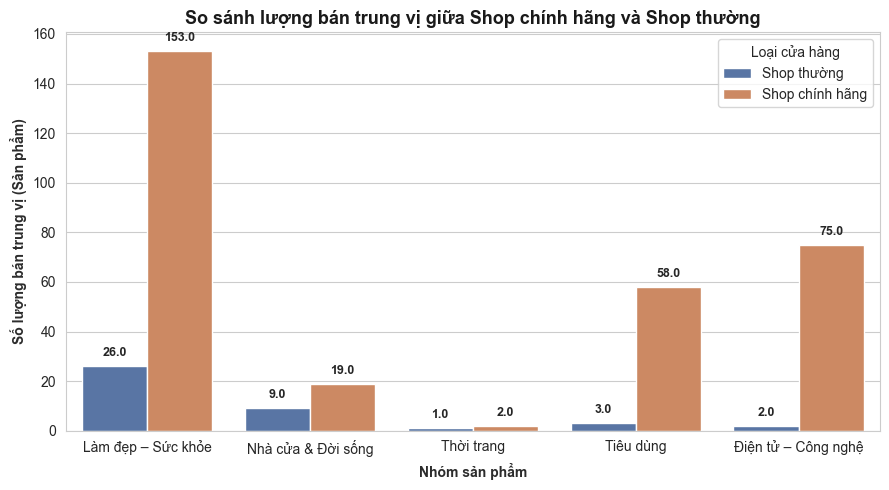

# **Câu 5: Một số từ khóa "giật tít" trong tên sản phẩm có ảnh hưởng đến điểm xếp hạng trung bình không?**

- **What is the question?**: Một số từ khóa "giật tít" trong tên sản phẩm có ảnh hưởng đến điểm xếp hạng trung bình không?

- **What are benefits of finding the answer?**: Giúp người bán sàng lọc bộ từ khóa "vàng" mang lại uy tín và tránh những từ khóa vô tình gây áp lực lên kỳ vọng khách hàng, dẫn đến đánh giá thấp.

- **How to find the answers of questions by using data**: Thực hiện phân tích tác động (Impact Analysis) bằng cách tính toán hiệu số giữa Rating trung bình của nhóm "Có từ khóa" và nhóm "Không có từ khóa". Kết quả được thể hiện qua biểu đồ Impact Score (màu xanh cho tích cực, màu đỏ cho tiêu cực) để chỉ ra lực "kéo" điểm của từng từ khóa.

- **Insight**: Thông thường ta nghĩ đồ chính hãng sẽ được đánh giá cao hơn, nhưng dữ liệu lại cho thấy điều ngược lại. Điều này phản ánh một quy luật tâm lý cực kỳ quan trọng: Sự hài lòng không đến từ chất lượng tuyệt đối, mà đến từ khoảng cách giữa kỳ vọng và thực tế. Khách mua đồ "Siêu rẻ", "Sale", "Giảm" có kỳ vọng thấp, nên khi nhận hàng thấy ổn họ sẽ rất hài lòng. Ngược lại, khách mua đồ "Chính hãng", "Xịn", có "Bảo hành" có kỳ vọng cực cao, họ soi xét từng chi tiết nhỏ nhất, dẫn đến việc dễ thất vọng.

- **Chiến lược**: Với phân khúc bình dân, hãy dùng các từ "Siêu rẻ", "Sale", "Giảm" để hút khách vì thực tế nó đang giúp bạn tích lũy điểm đánh giá trung bình tốt. Nếu dùng từ "Chính hãng", "Bảo hành" cửa hàng bắt buộc phải hoàn hảo ở khâu đóng gói và phản hồi chat, vì nhóm khách này cực kỳ khó chiều.

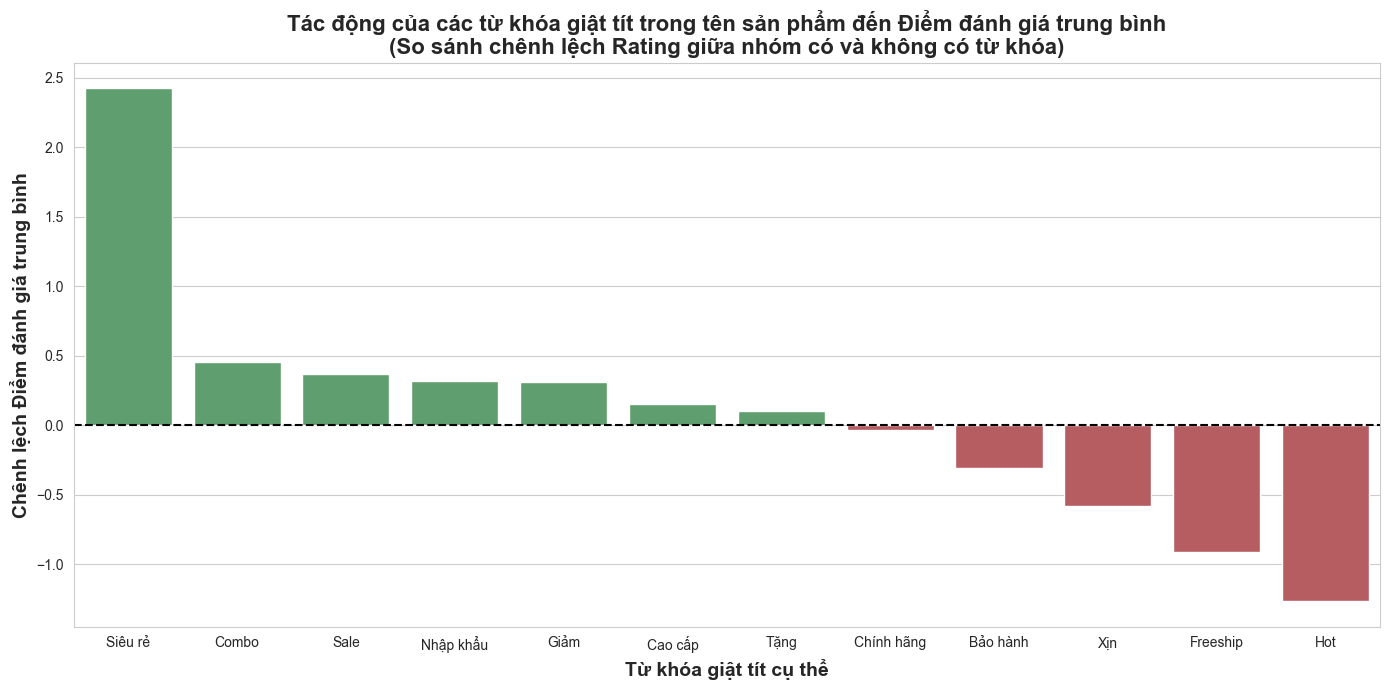

# **Câu 6: Mối quan hệ giữa số lượng người theo dõi của cửa hàng và số lượng bán của các sản phẩm là gì?**

- **What is the question?**: Mối quan hệ giữa số lượng người theo dõi của cửa hàng và số lượng bán của các sản phẩm là gì?

- **What are benefits of finding the answer?**: Giúp người bán đánh giá giá trị thực của việc chạy quảng cáo hoặc chương trình nhằm mục đích tăng follow cho cửa hàng, liệu nhiều follow có thực sự tăng lượng hàng bán ra không.

- **How to find the answers of questions by using data**: Sử dụng biểu đồ phân tán (Scatter plot) với thang đo Log-Log (logarit cả 2 trục) để "giãn" dữ liệu từ shop nhỏ đến shop lớn. Vẽ thêm đường hồi quy (Trendline) để xác định xu hướng: nếu đường dốc lên, follower thực sự giúp tăng đơn.

- **Insight**: Lượng người theo dõi đóng vai trò là kênh truyền thông 0 đồng. Biểu đồ cho thấy tống số follower tỉ lệ thuận với doanh số. Khi đạt đến một ngưỡng follower nhất định, shop bắt đầu có lượng đơn hàng tự nhiên ổn định mà không còn phụ thuộc quá nhiều vào chi phí quảng cáo.

- **Chiến lược**: Thay vì chỉ chạy quảng cáo để bán một đơn hàng rồi thôi, shop nên dùng ngân sách đó để thu hút follower qua voucher, quà tặng, ... Điều này giúp giảm chi phí thu hút khách hàng về lâu dài.

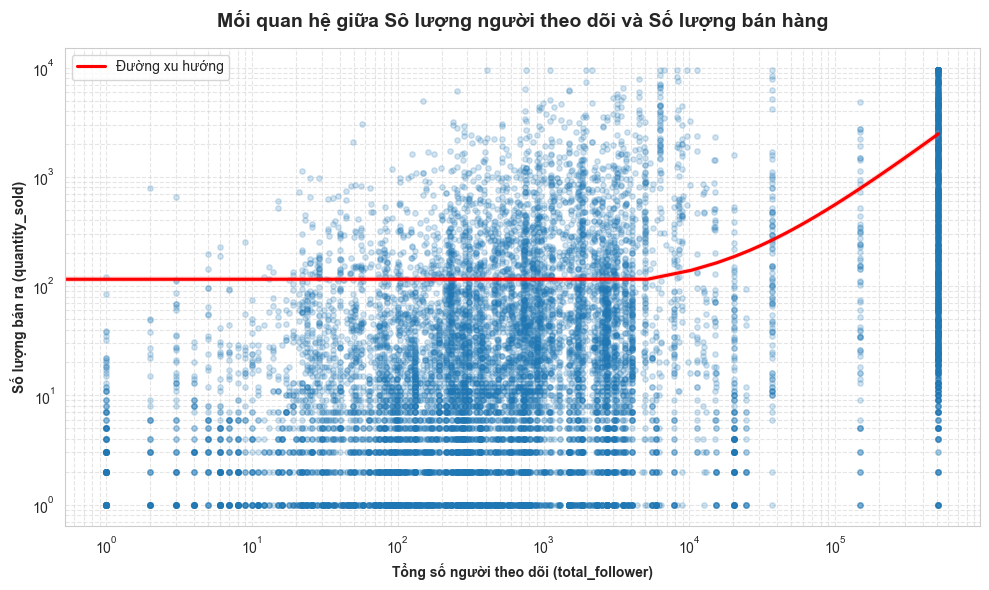

# **Câu 7: Mức độ chi tiết của tiêu đề sản phẩm có mối quan hệ gì với điểm đánh giá trung bình hay số lượng bán ra không?**

- **What is the question?**: Mức độ chi tiết của tiêu đề sản phẩm có mối quan hệ gì với điểm đánh giá trung bình hay số lượng bán ra không?

- **What are benefits of finding the answer?**: Giúp người bán biết cách đặt tiêu đề vừa đủ thông tin để thu hút khách hàng. Hiểu được độ dài tiêu đề nào thường đi kèm với đánh giá tốt, từ đó tránh việc viết tiêu đề gây hiểu lầm dẫn đến khách đánh giá thấp.

- **How to find the answers of questions by using data**: Chia độ dài tiêu đề `name_word_count` thành các nhóm (ví dụ: <10 từ, 10-20 từ, ...) và sử dụng biểu đồ Boxplot. Biểu đồ này sẽ cho thấy nhóm độ dài nào có mức điểm đánh giá trung bình ổn định nhất. Sử dụng biểu đồ phân tán (Scatter plot) kết hợp với đường hồi quy bậc 2 (đường cong Parabol). Đỉnh của đường cong này sẽ chỉ ra chính xác số lượng từ mà tại đó số lượng bán ra đạt giá trị cao nhất. Áp dụng Log Scale cho trục số lượng bán để quan sát rõ hơn sự thay đổi của doanh số theo từng mức độ dài tiêu đề khác nhau.

- **Insight**: 15-25 từ là "điểm ngọt". Đây là vấn đề về tâm lý học nhận thức. Tiêu đề dưới 10 từ gây cảm giác "treo đầu dê bán thịt chó" hoặc shop không đáng tin. Tiêu đề trên 40 từ gây hiện tượng quá tải thông tin, khiến khách hàng bị nhiễu.

- **Chiến lược**: Đặt tiêu đề sản phẩm đủ dài (~20 từ). Nó giúp lọc đúng khách hàng mục tiêu. Khi khách đọc kỹ và thấy đúng nhu cầu, họ mua và sẽ hài lòng. 

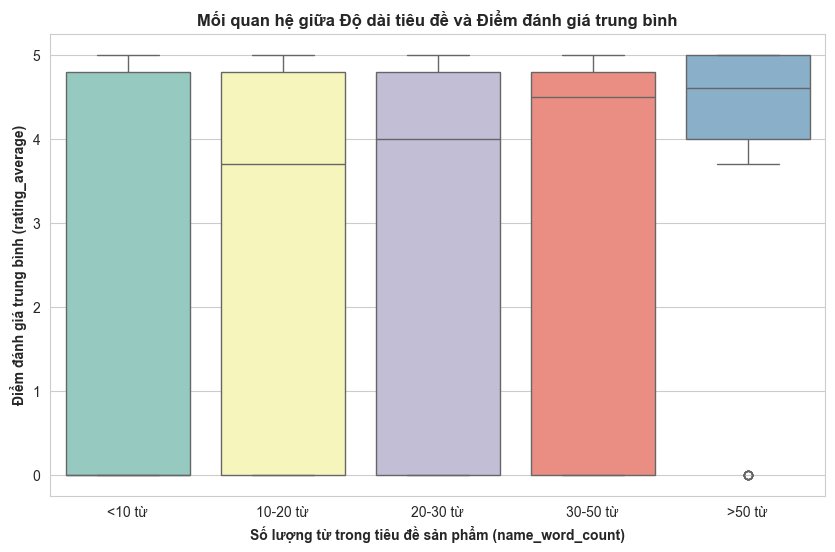

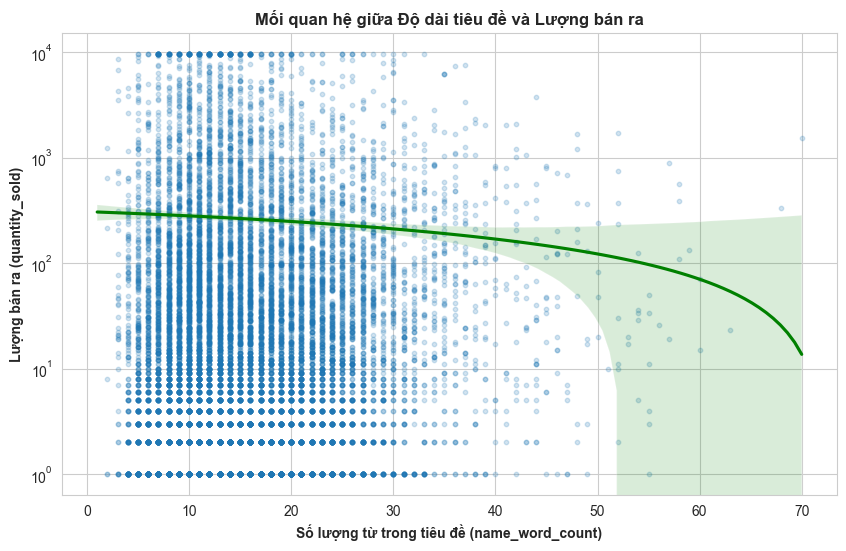